In [105]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.preprocessing import StandardScaler

import warnings
from sklearn import tree
import graphviz

import sys
sys.path.insert(0, '..')

from archspace import ArchSpace
from archspace import show_feature_scores, show_outcome_distributions, show_tradeoff_distribution
from archspace import show_quality_attribute_space2D

---

The processing of the Excel file needs to be done only once.

In [106]:
DATAPATH = './dataset-FormaliSE-2023-PoliMI.xlsx'

In [107]:
# Parse Excel file, the first row is the header
df = pd.read_excel(DATAPATH, sheet_name='data', header=0)
df

,ORCH_1_Dstop,ORCH_1_Drestart,ORCH_1_Fstop,ORCH_1_Frestart,PSCS__TAU,HUM_1_VEL,HUM_2_VEL,HUM_1_FW,HUM_1_FTG,HUM_2_FW,HUM_2_FTG,HUM_2_POS,ROB_1_VEL,ROB_1_CHG,PRSCS_LOWER_BOUND,PRSCS_UPPER_BOUND,FTG_HUM_1,FTG_HUM_2
0,6.869001,2.671202,0.731399,0.116786,376,39.227715,87.034458,foc,y/h,free,e/u,"2903.97, 230.19",31.854988,11.500305,0.901855,1.000000,0.0736+-0.0002,0.8817+-0.0000
1,7.351851,3.290670,0.553803,0.169180,326,59.748092,85.415259,free,e/h,foc,y/u,"3048.30, 502.54",57.888067,11.177836,0.901855,1.000000,0.0398+-0.0077,0.6668+-0.0083
2,5.882595,3.229829,0.534793,0.162923,479,43.435460,65.091766,distr,e/u,distr,y/s,"2833.24, 364.23",74.903043,11.213808,0.033724,0.133311,0.8049+-0.0167,0.0327+-0.0327
3,6.000023,2.921623,0.694557,0.138994,483,91.729516,35.615705,free,e/u,free,e/h,"120.30, 274.72",35.183258,12.201164,0.000000,0.098145,0.9985+-0.0000,0.0000+-0.0000
4,7.441865,3.136337,0.728687,0.172212,644,39.669024,78.553527,free,y/s,free,y/s,"1425.68, 583.33",31.624500,12.389621,0.901855,1.000000,0.2043+-0.0360,0.1207+-0.0206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,7.184872,2.213405,0.544372,0.392397,522,76.746811,86.502888,distr,e/h,distr,y/u,"822.13, 224.59",68.004788,11.832242,0.273616,0.373460,0.0158+-0.0158,0.5545+-0.0153
996,5.356650,2.617054,0.500230,0.393566,322,94.598568,82.088802,distr,y/u,free,y/u,"1960.13, 585.92",95.812194,11.391263,0.000000,0.098145,0.6968+-0.0528,0.2966+-0.2966
997,6.172075,2.712081,0.781733,0.395595,323,86.200621,49.840649,foc,e/s,distr,y/s,"1358.57, 246.46",85.999127,11.114076,0.000000,0.098145,0.1584+-0.0021,0.0642+-0.0523
998,6.456292,3.853920,0.552559,0.354998,430,62.978763,38.433739,free,y/s,free,y/u,"954.11, 703.03",42.628408,11.958524,0.901855,1.000000,0.1565+-0.0830,0.8148+-0.0023


In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ORCH_1_Dstop       1000 non-null   float64
 1   ORCH_1_Drestart    1000 non-null   float64
 2   ORCH_1_Fstop       1000 non-null   float64
 3   ORCH_1_Frestart    1000 non-null   float64
 4   PSCS__TAU          1000 non-null   int64  
 5   HUM_1_VEL          1000 non-null   float64
 6   HUM_2_VEL          1000 non-null   float64
 7   HUM_1_FW           1000 non-null   object 
 8   HUM_1_FTG          1000 non-null   object 
 9   HUM_2_FW           1000 non-null   object 
 10  HUM_2_FTG          1000 non-null   object 
 11  HUM_2_POS          1000 non-null   object 
 12  ROB_1_VEL          1000 non-null   float64
 13  ROB_1_CHG          1000 non-null   float64
 14  PRSCS_LOWER_BOUND  1000 non-null   float64
 15  PRSCS_UPPER_BOUND  1000 non-null   float64
 16  FTG_HUM_1          1000 n

In [109]:
# This is a workaround to keep 2 objectives (as all the scripts expect at least 2 objectives)
# df['PRSCS_UPPER_BOUND1'] = df['PRSCS_UPPER_BOUND'].copy() 
# df['PRSCS_UPPER_BOUND2'] = df['PRSCS_UPPER_BOUND'].copy() 
df['DUMMY'] = 1.0
# df.drop(columns=['PRSCS_UPPER_BOUND'], axis=1, inplace=True)

# Keep only columns with float or int values
df = df.select_dtypes(include=[np.float64, np.int64])
# Convert int columns to float
df = df.astype(float)
out_filename = DATAPATH.replace('.xlsx', '.csv')
# Save the DataFrame to a CSV file
df.to_csv(out_filename, index=False)
df

,ORCH_1_Dstop,ORCH_1_Drestart,ORCH_1_Fstop,ORCH_1_Frestart,PSCS__TAU,HUM_1_VEL,HUM_2_VEL,ROB_1_VEL,ROB_1_CHG,PRSCS_LOWER_BOUND,PRSCS_UPPER_BOUND,DUMMY
0,6.869001,2.671202,0.731399,0.116786,376.0,39.227715,87.034458,31.854988,11.500305,0.901855,1.000000,1.0
1,7.351851,3.290670,0.553803,0.169180,326.0,59.748092,85.415259,57.888067,11.177836,0.901855,1.000000,1.0
2,5.882595,3.229829,0.534793,0.162923,479.0,43.435460,65.091766,74.903043,11.213808,0.033724,0.133311,1.0
3,6.000023,2.921623,0.694557,0.138994,483.0,91.729516,35.615705,35.183258,12.201164,0.000000,0.098145,1.0
4,7.441865,3.136337,0.728687,0.172212,644.0,39.669024,78.553527,31.624500,12.389621,0.901855,1.000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,7.184872,2.213405,0.544372,0.392397,522.0,76.746811,86.502888,68.004788,11.832242,0.273616,0.373460,1.0
996,5.356650,2.617054,0.500230,0.393566,322.0,94.598568,82.088802,95.812194,11.391263,0.000000,0.098145,1.0
997,6.172075,2.712081,0.781733,0.395595,323.0,86.200621,49.840649,85.999127,11.114076,0.000000,0.098145,1.0
998,6.456292,3.853920,0.552559,0.354998,430.0,62.978763,38.433739,42.628408,11.958524,0.901855,1.000000,1.0


In [110]:
# df.columns

In [111]:
from natsort import natsorted
import itertools

class ArchSpacePoliMilano(ArchSpace):

    RESPONSE_TIME_LABELS = ['low', 'average', 'high']
    UTILIZATION_LABELS = ['low', 'average', 'high']

    ALL_TRADEOFF_LABELS = natsorted([','.join(t) for t in itertools.product(*[RESPONSE_TIME_LABELS, UTILIZATION_LABELS])])

    ALL_LABELS = dict()
    # ALL_LABELS['PRSCS_UPPER_BOUND1'] = RESPONSE_TIME_LABELS
    # ALL_LABELS['PRSCS_UPPER_BOUND2'] = UTILIZATION_LABELS
    ALL_LABELS['PRSCS_UPPER_BOUND'] = RESPONSE_TIME_LABELS
    ALL_LABELS['DUMMY'] = UTILIZATION_LABELS

    INPUT_PARAMETERS = ['HUM_1_VEL', 'HUM_2_VEL', 'ROB_1_VEL'] 
    OUTPUTS = ['PRSCS_UPPER_BOUND', 'DUMMY']  # ['PRSCS_UPPER_BOUND1', 'PRSCS_UPPER_BOUND2'] 

    def load_results(self, path):

        df = pd.read_csv(path)
        self.experiments_df_ = df[self.INPUT_PARAMETERS].copy()
        self.experiments_df_.index.name = 'scenario'
        self.experiments_df_.reset_index(inplace=True)
        self.experiments_df_['model'] = 'poli_milano'
        self.experiments_df_['policy'] = 0 #np.nan #float('nan')
        self.experiments_df_['policy'] = self.experiments_df_['policy'].astype('category')

        self.outcomes_df_ = df[self.OUTPUTS].copy()

        print(self.experiments_df_.shape)
        print(self.outcomes_df_.shape)

        return self.experiments_df_, self.outcomes_df_

    def get_configurations(self):
        all_configs = set(self.experiments_df_['policy'])
        return list(all_configs) #[[x] for x in all_configs]

---

### EDA (Explorative Data Analysis)

In [112]:
# Load the dataset for the pattern
my_space = ArchSpacePoliMilano()
my_space.create_model('poli_milano')

csv_filename = DATAPATH.replace('.xlsx', '.csv')
experiments_df, outcomes_df = my_space.load_results(csv_filename)

print(len(my_space.get_configurations()), "configurations")

(1000, 6)
(1000, 2)
1 configurations


In [113]:
experiments_df

,scenario,HUM_1_VEL,HUM_2_VEL,ROB_1_VEL,model,policy
0,0,39.227715,87.034458,31.854988,poli_milano,0
1,1,59.748092,85.415259,57.888067,poli_milano,0
2,2,43.435460,65.091766,74.903043,poli_milano,0
3,3,91.729516,35.615705,35.183258,poli_milano,0
4,4,39.669024,78.553527,31.624500,poli_milano,0
...,...,...,...,...,...,...
995,995,76.746811,86.502888,68.004788,poli_milano,0
996,996,94.598568,82.088802,95.812194,poli_milano,0
997,997,86.200621,49.840649,85.999127,poli_milano,0
998,998,62.978763,38.433739,42.628408,poli_milano,0


In [114]:
experiments_df.describe()

,scenario,HUM_1_VEL,HUM_2_VEL,ROB_1_VEL
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,66.202550,64.392474,64.598722
std,288.819436,19.654453,20.617292,20.584348
min,0.000000,30.137567,30.048694,30.053797
25%,249.750000,50.036645,45.830968,46.581660
50%,499.500000,66.548686,65.247245,64.844251
75%,749.250000,82.989052,82.391220,82.283427
max,999.000000,99.844128,99.990875,99.914865


In [115]:
# experiments_df.info()

In [116]:
outcomes_df

,PRSCS_UPPER_BOUND,DUMMY
0,1.000000,1.0
1,1.000000,1.0
2,0.133311,1.0
3,0.098145,1.0
4,1.000000,1.0
...,...,...
995,0.373460,1.0
996,0.098145,1.0
997,0.098145,1.0
998,1.000000,1.0


In [117]:
outcomes_df.describe()

,PRSCS_UPPER_BOUND,DUMMY
count,1000.000000,1000.0
mean,0.459396,1.0
std,0.383786,0.0
min,0.098145,1.0
25%,0.098145,1.0
50%,0.303959,1.0
75%,0.954924,1.0
max,1.000000,1.0


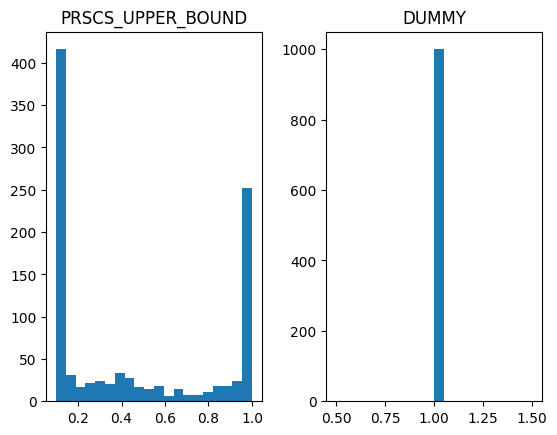

In [118]:
# Show distribution of the quality-attribute metrics
outcomes_df.hist(bins=20, grid=False)
plt.show()

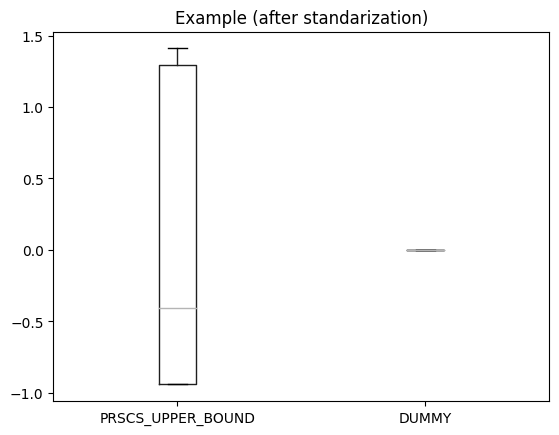

In [119]:
# Scaling the data for showing boxplots and outliers (if any)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(outcomes_df)
scaled_df = pd.DataFrame(scaled_data, columns=outcomes_df.columns)
scaled_df.boxplot(grid=False)
plt.title('Example (after standarization)')
plt.show()

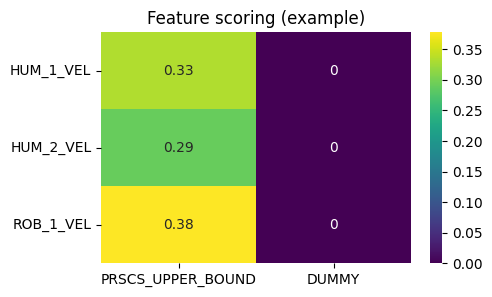

,PRSCS_UPPER_BOUND,DUMMY
0,,
HUM_1_VEL,0.332264,0.0
HUM_2_VEL,0.289812,0.0
ROB_1_VEL,0.377924,0.0


In [120]:
policy_size = (5,3)
filter_params = None # Screening most important parameters 
fs = show_feature_scores(my_space, title='Feature scoring (example)', size=policy_size) #, filename=None)  
fs

In [121]:
my_policies = my_space.get_configurations()
my_policies

[0]

In [122]:
outcomes_df.describe()

,PRSCS_UPPER_BOUND,DUMMY
count,1000.000000,1000.0
mean,0.459396,1.0
std,0.383786,0.0
min,0.098145,1.0
25%,0.098145,1.0
50%,0.303959,1.0
75%,0.954924,1.0
max,1.000000,1.0


Absolute ranges: [(0.097, 1.0), (0.009, 1.0)]
PRSCS_UPPER_BOUND [-0.0030000000000000027, 0.36466666666666675, 0.7323333333333335, 1.1]
DUMMY [-0.09100000000000001, 0.306, 0.7030000000000001, 1.1]


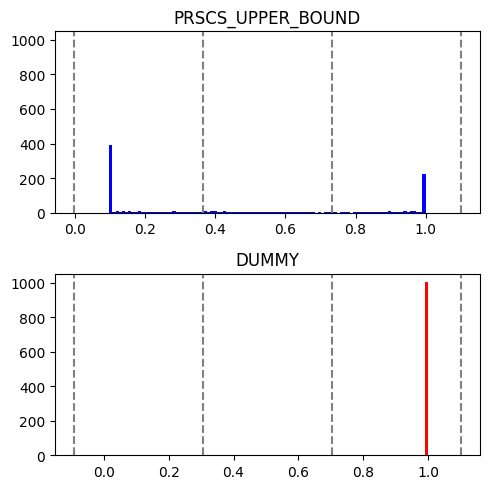

In [123]:
# Discretize the outcomes into labels
MIN_OUTPUT1, MAX_OUTPUT1 = (0.097, 1.0)
MIN_OUTPUT2, MAX_OUTPUT2 = (0.009, 1.0)
MIN_MAX_RANGES = [(MIN_OUTPUT1, MAX_OUTPUT1), (MIN_OUTPUT2, MAX_OUTPUT2)]
print('Absolute ranges:', MIN_MAX_RANGES)

_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES) # 3 bins for each objective

# Show the tradeoff distribution
_ = show_outcome_distributions(my_space, mins_maxs=MIN_MAX_RANGES, size=(5,5))

Computing robustness for all configurations (whole space)...


100%|██████████| 1/1 [00:00<00:00, 53.17it/s]


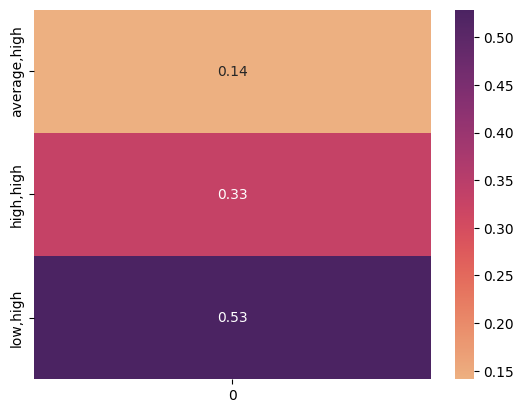

,0
"average,high",0.141
"high,high",0.330
"low,high",0.529


In [124]:
print("Computing robustness for all configurations (whole space)...")
matrix_df = my_space.compute_robustness_matrix()
# df.to_csv('./gateway_offloading_robustness_matrix.csv')

sns.heatmap(matrix_df, annot=True, fmt=".2f", cmap='flare')
plt.show()
matrix_df

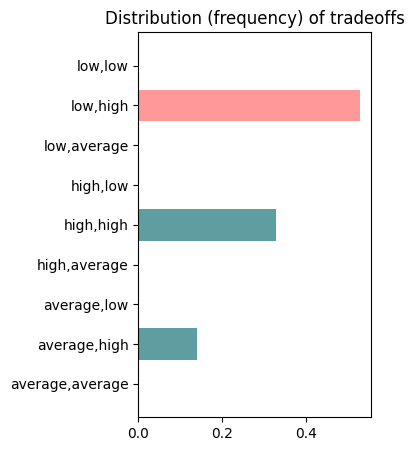

In [125]:
# Alternative view of traeoffs
show_tradeoff_distribution(my_space, size=(3,5))
# show_tradeoff_distribution(my_space, size=(4,3), in2D=True)

In [126]:
# Show the ranges for each quality-attribute label
label_values_df = my_space.describe_labels(n_bins=3)
label_values_df

,objective,min,max,label
0,PRSCS_UPPER_BOUND,-0.001855,0.365430,low
1,PRSCS_UPPER_BOUND,0.365430,0.732715,average
2,PRSCS_UPPER_BOUND,0.732715,1.100000,high
3,DUMMY,0.900000,0.966667,low
4,DUMMY,0.966667,1.033333,average
5,DUMMY,1.033333,1.100000,high


---

### Model training

In [127]:
# Split dataset for ML analysis (train/test sets). Also outliers removal (beyond 3 standard deviations)
X_train, X_test, y_train, y_test = my_space.split_dataset(test_size=0.25, remove_outliers=3)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(1000, 8) 1000
Removing outliers ... 3
Instances to remove (outliers): set()
Instances to remove (not enough tradeoffs): set()
{'average,high', 'low,high', 'high,high'}
(1000, 8) 1000
(750, 8) (750, 2) (250, 8) (250, 2)


In [128]:
# X_train[['PRSCS_UPPER_BOUND1', 'PRSCS_UPPER_BOUND2']].describe()
X_train[['PRSCS_UPPER_BOUND', 'DUMMY']].describe()

,PRSCS_UPPER_BOUND,DUMMY
count,750.000000,750.0
mean,0.457269,1.0
std,0.383085,0.0
min,0.098145,1.0
25%,0.098145,1.0
50%,0.303959,1.0
75%,0.948030,1.0
max,1.000000,1.0


Experiments: (750, 6)


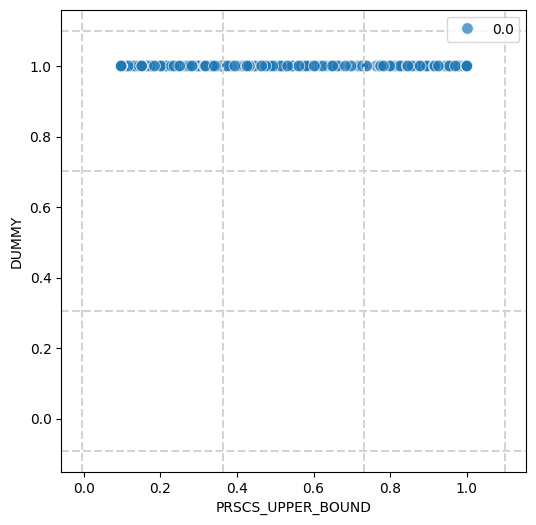

In [129]:
# Display the training set
my_space.import_dataset(X_train, y_train)
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
print("Experiments:", my_space.experiments_df_.shape)

df = my_space.outcomes_df_.copy()
df['decision'] = my_space.experiments_df_['policy']
show_quality_attribute_space2D(df, MIN_MAX_RANGES, 
                               # qualities=['PRSCS_UPPER_BOUND1', 'PRSCS_UPPER_BOUND2'], 
                               qualities=['PRSCS_UPPER_BOUND', 'DUMMY'], 
                               alpha=0.7)

In [130]:
# X_test[['PRSCS_UPPER_BOUND1', 'PRSCS_UPPER_BOUND2']].describe()
X_test[['PRSCS_UPPER_BOUND', 'DUMMY']].describe()

,PRSCS_UPPER_BOUND,DUMMY
count,250.000000,250.0
mean,0.465777,1.0
std,0.386580,0.0
min,0.098145,1.0
25%,0.098145,1.0
50%,0.304675,1.0
75%,0.966276,1.0
max,1.000000,1.0


Experiments: (250, 6)


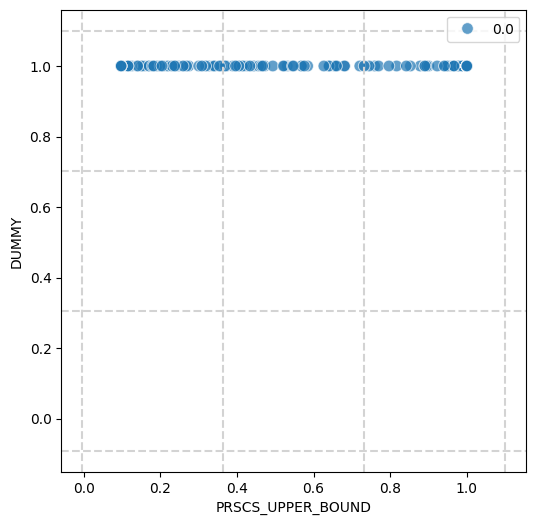

In [131]:
# Display the test set
my_space.import_dataset(X_test, y_test)
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
print("Experiments:", my_space.experiments_df_.shape)

df = my_space.outcomes_df_.copy()
df['decision'] = my_space.experiments_df_['policy']
show_quality_attribute_space2D(df, MIN_MAX_RANGES, 
                               # qualities=['PRSCS_UPPER_BOUND1', 'PRSCS_UPPER_BOUND2'], 
                                 qualities=['PRSCS_UPPER_BOUND', 'DUMMY'],
                               alpha=0.7)

  Computing robustness for all configurations (train set)...
Counter({'low,high': 397, 'high,high': 247, 'average,high': 106})


100%|██████████| 1/1 [00:00<00:00, 57.56it/s]


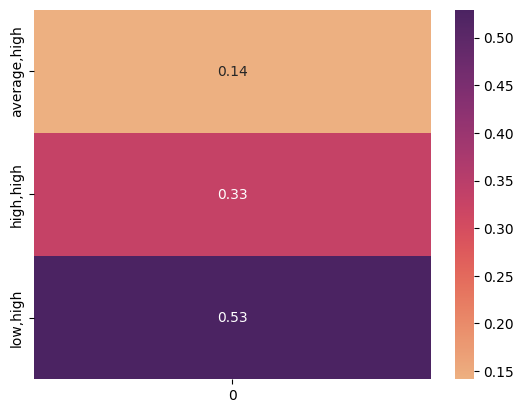

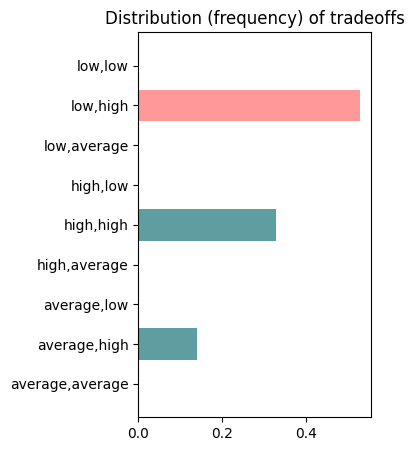

,0
"average,high",0.141333
"high,high",0.329333
"low,high",0.529333


In [132]:
# Work first with the train set

my_space.import_dataset(X_train, y_train)
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES) # 3 bins for each objective

print("  Computing robustness for all configurations (train set)...")
print(my_space.available_tradeoffs_)

matrix_df = my_space.compute_robustness_matrix()
sns.heatmap(matrix_df, annot=True, fmt=".2f", cmap='flare')

show_tradeoff_distribution(my_space, size=(3,5))
# show_tradeoff_distribution(my_space, size=(4,3), in2D=True)

matrix_df

  Computing robustness for all configurations (test set)...
Counter({'low,high': 132, 'high,high': 83, 'average,high': 35})


100%|██████████| 1/1 [00:00<00:00, 129.75it/s]


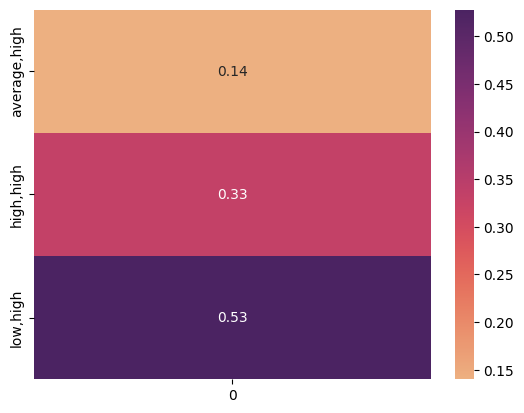

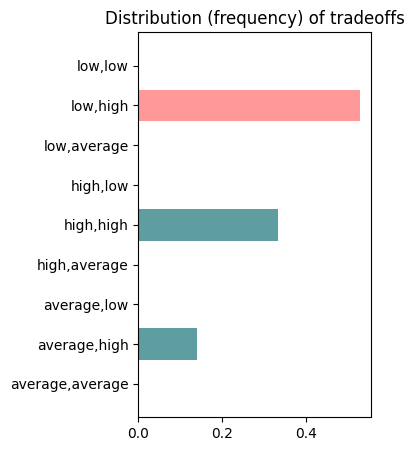

,0
"average,high",0.140
"high,high",0.332
"low,high",0.528


In [133]:
my_space.import_dataset(X_test, y_test)
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)

print("  Computing robustness for all configurations (test set)...")
print(my_space.available_tradeoffs_)

matrix_df = my_space.compute_robustness_matrix()
sns.heatmap(matrix_df, annot=True, fmt=".2f", cmap='flare')

show_tradeoff_distribution(my_space, size=(3,5))
# show_tradeoff_distribution(my_space, size=(4,3), in2D=True)

matrix_df

In [134]:
# Run PRIM for each tradeoff using the train set, and then evaluate the robustness achieved on the test set
warnings.filterwarnings('ignore')
# my_space.import_dataset(X_train, y_train)

kp = list(fs.index)
print("Key parameters for PRIM:", kp)
my_policies = my_space.get_configurations()
qa_labels = list(my_space.available_tradeoffs_.keys())
qa_labels.sort()
for qa_label in qa_labels:
    # Also loop over the different policies (configurations)?
    # for policy in my_policies:
        policy = my_policies[0]  # use the first policy for now
        my_space.import_dataset(X_train, y_train)
        _ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
        n = my_space.available_tradeoffs_[qa_label]
        
        if n > 0:
            print()
            print("Checking (with PRIM) ----")
            property_to_check = my_space.get_property_box(qa_label)
            print("  Property: ", qa_label, property_to_check)
            print("  Policy: ", policy)

            try:
                box1, prange, prim_model = my_space.run_prim(property_to_check, policy=policy,
                                                         threshold=0.8, method='rhodium', # 'emaw' 'rhodium'
                                                         key_parameters=kp, verbose=False)
                # print(box1)
                print("  New ranges:",  prange)
            except Exception:
                print("EXCEPTION triggered!") 
                pass

            my_space.import_dataset(X_test, y_test)
            my_space.adjust_parameters(prange)
            _ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
            print("  Experiments:", my_space.experiments_df_.shape)
            print(my_space.compute_robustness(policy, qa_label))

            print("  Computing robustness for all configurations (test set) ...")
            df = my_space.compute_robustness_matrix()
            print(df)
            # plt.show()

my_space.import_dataset(X_train, y_train)
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)


Key parameters for PRIM: ['HUM_1_VEL', 'HUM_2_VEL', 'ROB_1_VEL']

Checking (with PRIM) ----
  Property:  average,high {'PRSCS_UPPER_BOUND': (0.36466666666666675, 0.7323333333333335), 'DUMMY': (0.7030000000000001, 1.1)}
  Policy:  0
  New ranges: {'HUM_1_VEL': {'min': 45.2438705522046, 'max': 85.31302373236934}, 'ROB_1_VEL': {'min': 56.03111948660165, 'max': 90.08610588397704}}
  Experiments: (70, 6)
(0.24285714285714285, 'average,high')
  Computing robustness for all configurations (test set) ...


100%|██████████| 1/1 [00:00<00:00, 348.68it/s]

                     0
average,high  0.242857
high,high     0.342857
low,high      0.414286



Checking (with PRIM) ----
  Property:  high,high {'PRSCS_UPPER_BOUND': (0.7323333333333335, 1.1), 'DUMMY': (0.7030000000000001, 1.1)}
  Policy:  0
  New ranges: {'HUM_1_VEL': {'min': 33.524467255938646, 'max': 81.52867324704451}, 'HUM_2_VEL': {'min': 38.505570132448, 'max': 99.9499765529545}, 'ROB_1_VEL': {'min': 52.942476613101505, 'max': 95.3237971866759}}
  Experiments: (89, 6)
(0.4157303370786517, 'high,high')
  Computing robustness for all configurations (test set) ...


100%|██████████| 1/1 [00:00<00:00, 332.75it/s]


                     0
average,high  0.191011
high,high     0.415730
low,high      0.393258

Checking (with PRIM) ----
  Property:  low,high {'PRSCS_UPPER_BOUND': (-0.0030000000000000027, 0.36466666666666675), 'DUMMY': (0.7030000000000001, 1.1)}
  Policy:  0
  New ranges: {'HUM_2_VEL': {'min': 30.1165017622565, 'max': 92.72931080405081}, 'ROB_1_VEL': {'min': 30.0537969849623, 'max': 93.3793420761717}}
  Experiments: (203, 6)
(0.5320197044334976, 'low,high')
  Computing robustness for all configurations (test set) ...


100%|██████████| 1/1 [00:00<00:00, 204.54it/s]

                     0
average,high  0.133005
high,high     0.334975
low,high      0.532020


With PRIM, we can see the following improvements:
* average, average: 0.14 --> 0.31
* high, high: 0.33 --> 0.46
* low, low: 0.53 --> 0.92

In [135]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

def check_cart_performance(my_space, X_train, y_train, X_test, y_test, random_state=42):
    """
    Check the performance of a CART model on the training and test sets.
    """
    # Training set
    X = X_train[ArchSpacePoliMilano.INPUT_PARAMETERS]
    y = my_space._get_cluster_labels(y_train, encode=True)

    # Train a decision tree classifier
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X, y)

    path = clf.cost_complexity_pruning_path(X, y)
    ccp_alphas, impurities = path.ccp_alphas, path.impurities
    print(len(ccp_alphas), "alphas") #, "ccp_alphas=", ccp_alphas)

    # Train models for each alpha
    models = []
    print("Training models for each alpha...")
    for alpha in ccp_alphas:
        clf = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
        clf.fit(X, y)
        models.append(clf)
    print("Trained", len(models), "models.")

    # Evaluate and plot accuracy vs. alpha
    # train_scores = [clf.score(X, y) for clf in models]
    f1_train_scores = [f1_score(y, clf.predict(X), average='weighted') for clf in models]

    # Test set
    X =  X_test[ArchSpacePoliMilano.INPUT_PARAMETERS]
    y = my_space._get_cluster_labels(y_test, encode=True)
    # test_scores = [clf.score(X, y) for clf in models]
    f1_test_scores = [f1_score(y, clf.predict(X), average='weighted') for clf in models]

    plt.figure(figsize=(5, 5))
    # plt.scatter(ccp_alphas, train_scores, label='Train Accuracy', alpha=0.5)
    # plt.scatter(ccp_alphas, test_scores, label='Test Accuracy', alpha=0.5)
    plt.scatter(ccp_alphas, f1_train_scores, label='Train Accuracy', alpha=0.5)
    plt.scatter(ccp_alphas, f1_test_scores, label='Test Accuracy', alpha=0.5)
    plt.xlabel('Alpha')
    plt.ylabel('F1-measure') #'Accuracy')
    plt.legend()
    plt.title('Accuracy vs Alpha for Pruned Trees')
    plt.show()

129 alphas
Training models for each alpha...
Trained 129 models.


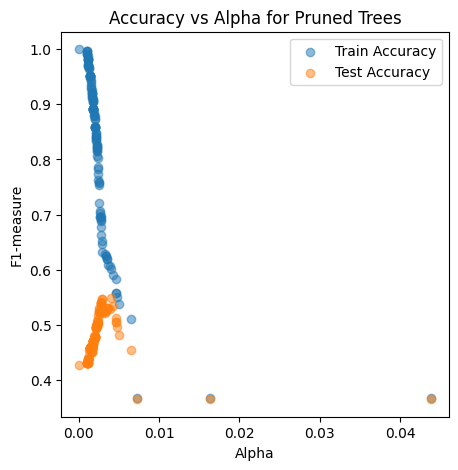

In [136]:
check_cart_performance(my_space, X_train, y_train, X_test, y_test)

In [137]:
policy = my_policies[0]  # use the first policy for now # Unique configuration

my_space.import_dataset(X_train, y_train)
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
# n = my_space.available_tradeoffs_[qa_label]

kp = list(fs.index)
print("Key parameters for CART:", kp)
print("Checking (with CART) ----")
print("Checking (with CART) ---- all properties")
print("  Policy: ", policy)


triple_rules, ranges, cart_model = my_space.run_cart(key_parameters=kp, prune_tree=True)
clf = cart_model.clf
print("nodes:", clf.tree_.node_count, "leaves:", clf.get_n_leaves())
print("  New ranges:")
for r in ranges.keys():
    print("\t", r, ranges[r])
print("Rules:")
for t in triple_rules:
    print(t)

print()
print("Testing ---- ")
qa_labels = list(my_space.available_tradeoffs_.keys())
qa_labels.sort()
for qa_label in ranges: # qa_labels:
    print()
    property_to_check = my_space.get_property_box(qa_label)
    prange = ranges[qa_label]
    print("  Property: ", qa_label, property_to_check)
    print("  Range:",  prange)
    
    my_space.import_dataset(X_test, y_test)
    my_space.adjust_parameters(prange)
    n = my_space.available_tradeoffs_[qa_label]
    if n > 0:
        _ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
        print("  Experiments:", my_space.experiments_df_.shape)
        if my_space.experiments_df_.shape[0] > 0:
            print(my_space.compute_robustness(policy, qa_label))

        print("  Computing robustness for all configurations (test set) ...")
        df = my_space.compute_robustness_matrix()
        print(df)
        # plt.show()
    else:
        print("  No experiments in this range")

Key parameters for CART: ['HUM_1_VEL', 'HUM_2_VEL', 'ROB_1_VEL']
Checking (with CART) ----
Checking (with CART) ---- all properties
  Policy:  0
(750, 3) Index(['HUM_1_VEL', 'HUM_2_VEL', 'ROB_1_VEL'], dtype='object')
None
Running CART ... 0.0026666666666666666
nodes: 393 leaves: 215
  New ranges:
	 low,high {'HUM_1_VEL': {'min': 69.616000001, 'max': inf}, 'ROB_1_VEL': {'min': 0, 'max': 47.456}}
	 high,high {'HUM_2_VEL': {'min': 38.580000000999995, 'max': 44.111}, 'HUM_1_VEL': {'min': 0, 'max': 75.183}, 'ROB_1_VEL': {'min': 55.15700000099999, 'max': 89.958}}
	 average,high {'HUM_2_VEL': {'min': 38.580000000999995, 'max': 74.276}, 'HUM_1_VEL': {'min': 75.18300000100001, 'max': 78.402}, 'ROB_1_VEL': {'min': 56.853000001, 'max': 69.268}}
Rules:
[('<=', 'ROB_1_VEL', 49.909), ('>', 'HUM_1_VEL', 60.143), ('>', 'HUM_1_VEL', 69.616), ('<=', 'ROB_1_VEL', 47.456), ('class', 'low,high', 0.99)]
[('>', 'ROB_1_VEL', 49.909), ('>', 'HUM_1_VEL', 93.768), ('<=', 'ROB_1_VEL', 68.373), ('class', 'low,high

100%|██████████| 1/1 [00:00<00:00, 596.97it/s]


                     0
average,high  0.041667
low,high      0.958333

  Property:  high,high {'PRSCS_UPPER_BOUND': (0.7323333333333335, 1.1), 'DUMMY': (0.7030000000000001, 1.1)}
  Range: {'HUM_2_VEL': {'min': 38.580000000999995, 'max': 44.111}, 'HUM_1_VEL': {'min': 0, 'max': 75.183}, 'ROB_1_VEL': {'min': 55.15700000099999, 'max': 89.958}}
  Experiments: (9, 6)
(0.4444444444444444, 'high,high')
  Computing robustness for all configurations (test set) ...


100%|██████████| 1/1 [00:00<00:00, 504.00it/s]


                     0
average,high  0.222222
high,high     0.444444
low,high      0.333333

  Property:  average,high {'PRSCS_UPPER_BOUND': (0.36466666666666675, 0.7323333333333335), 'DUMMY': (0.7030000000000001, 1.1)}
  Range: {'HUM_2_VEL': {'min': 38.580000000999995, 'max': 74.276}, 'HUM_1_VEL': {'min': 75.18300000100001, 'max': 78.402}, 'ROB_1_VEL': {'min': 56.853000001, 'max': 69.268}}
  Experiments: (1, 6)
(0.0, 'average,high')
  Computing robustness for all configurations (test set) ...


100%|██████████| 1/1 [00:00<00:00, 1307.04it/s]

            0
low,high  1.0


With CART, we can see the following results:
* average, average: 0.14 --> ? (nothing)
* high, high: 0.33 --> 0.42 (improvement)
* low, low: 0.53 --> 0.78 (improvement)

In [138]:
# Restore the train set for tree visualization
my_space.import_dataset(X_train, y_train)
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)

In [139]:
class_names =  [*Counter(my_space._get_cluster_labels())] # list(ranges.keys()) # my_space._get_cluster_labels()
dot_data = tree.export_graphviz(clf, out_file=None, feature_names=kp, class_names=class_names,
                                filled=True, rounded=True, special_characters=True)

graph = graphviz.Source(dot_data)

# print(tree.export_text(cart_model.clf))

# graph

---

### Inspection of results for specific tradeoffs (CART and PRIM)

In [140]:
# Select a target tradeoff to inspect
# qa_label = 'low,low' # 'high,high' 'low,low' 'average,average'
qa_label = 'high,high' # 'high,high' 'low,high' 'average,high'

In [141]:
# Run CART (again)
my_space.import_dataset(X_train, y_train)
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)

triple_rules, ranges, cart_model = my_space.run_cart(key_parameters=kp, prune_tree=True)
ranges

(750, 3) Index(['HUM_1_VEL', 'HUM_2_VEL', 'ROB_1_VEL'], dtype='object')
None
Running CART ... 0.0026666666666666666


{'low,high': {'HUM_1_VEL': {'min': 69.616000001, 'max': inf},
  'ROB_1_VEL': {'min': 0, 'max': 47.456}},
 'high,high': {'HUM_2_VEL': {'min': 38.580000000999995, 'max': 44.111},
  'HUM_1_VEL': {'min': 0, 'max': 75.183},
  'ROB_1_VEL': {'min': 55.15700000099999, 'max': 89.958}},
 'average,high': {'HUM_2_VEL': {'min': 38.580000000999995, 'max': 74.276},
  'HUM_1_VEL': {'min': 75.18300000100001, 'max': 78.402},
  'ROB_1_VEL': {'min': 56.853000001, 'max': 69.268}}}

In [142]:
# qa_label = 'average,average' # 'high,high' 'low,low' 'average,average'
property_to_check = my_space.get_property_box(qa_label)
print(qa_label, property_to_check)
prange = ranges[qa_label]
prange

high,high {'PRSCS_UPPER_BOUND': (0.7323333333333335, 1.1), 'DUMMY': (0.7030000000000001, 1.1)}


{'HUM_2_VEL': {'min': 38.580000000999995, 'max': 44.111},
 'HUM_1_VEL': {'min': 0, 'max': 75.183},
 'ROB_1_VEL': {'min': 55.15700000099999, 'max': 89.958}}

Reducing range for tradeoff: high,high {'PRSCS_UPPER_BOUND': (0.7323333333333335, 1.1), 'DUMMY': (0.7030000000000001, 1.1)}
New ranges: {'HUM_2_VEL': {'min': 38.580000000999995, 'max': 44.111}, 'HUM_1_VEL': {'min': 0, 'max': 75.183}, 'ROB_1_VEL': {'min': 55.15700000099999, 'max': 89.958}}
Experiments: (9, 6)


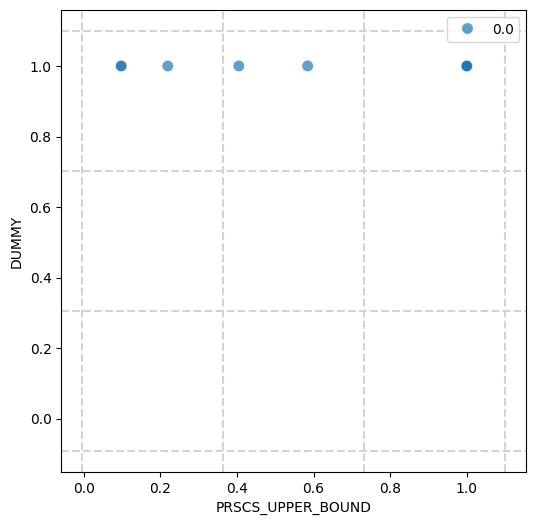

In [143]:
my_space.import_dataset(X_test, y_test)
# my_space.import_dataset(X_train, y_train)

print("Reducing range for tradeoff:", qa_label, property_to_check)
print("New ranges:",  prange)

my_space.adjust_parameters(prange)
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
print("Experiments:", my_space.experiments_df_.shape)

df = my_space.outcomes_df_.copy()
df['decision'] = my_space.experiments_df_['policy']
show_quality_attribute_space2D(df, MIN_MAX_RANGES, 
                               # qualities=['PRSCS_UPPER_BOUND1', 'PRSCS_UPPER_BOUND2'], 
                               qualities=['PRSCS_UPPER_BOUND', 'DUMMY'],
                               alpha=0.7)

---

In [144]:
# Run PRIM (again) and select a target tradeoff

my_space.import_dataset(X_train, y_train)

# qa_label = 'low,low' # 'fast,average' 'fast,high' 'average,average'
property_to_check = my_space.get_property_box(qa_label)
print(qa_label, property_to_check)

target_policy = '0'
# box1, prange, prim_model = my_space.run_prim(property_to_check, threshold=0.8, method='emaw', key_parameters=kp, policy=target_policy)
box1, prange, prim_model = my_space.run_prim(property_to_check, threshold=0.8, method='rhodium', key_parameters=kp)
prange

high,high {'PRSCS_UPPER_BOUND': (0.7323333333333335, 1.1), 'DUMMY': (0.7030000000000001, 1.1)}
Instances satisfying property: False    503
True     247
Name: count, dtype: int64
Total instances: (750, 3)
Running PRIM ... rhodium
5 possible boxes


{'HUM_1_VEL': {'min': 33.524467255938646, 'max': 81.52867324704451},
 'HUM_2_VEL': {'min': 38.505570132448, 'max': 99.9499765529545},
 'ROB_1_VEL': {'min': 52.942476613101505, 'max': 95.3237971866759}}

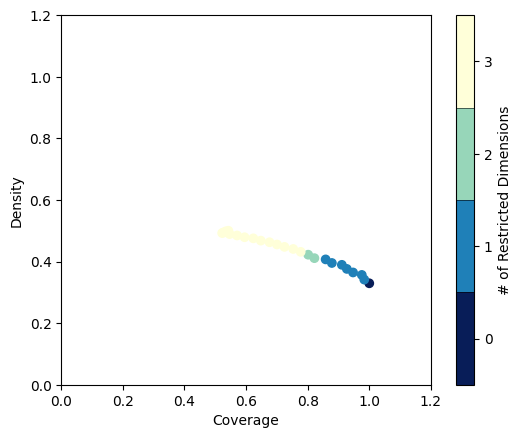

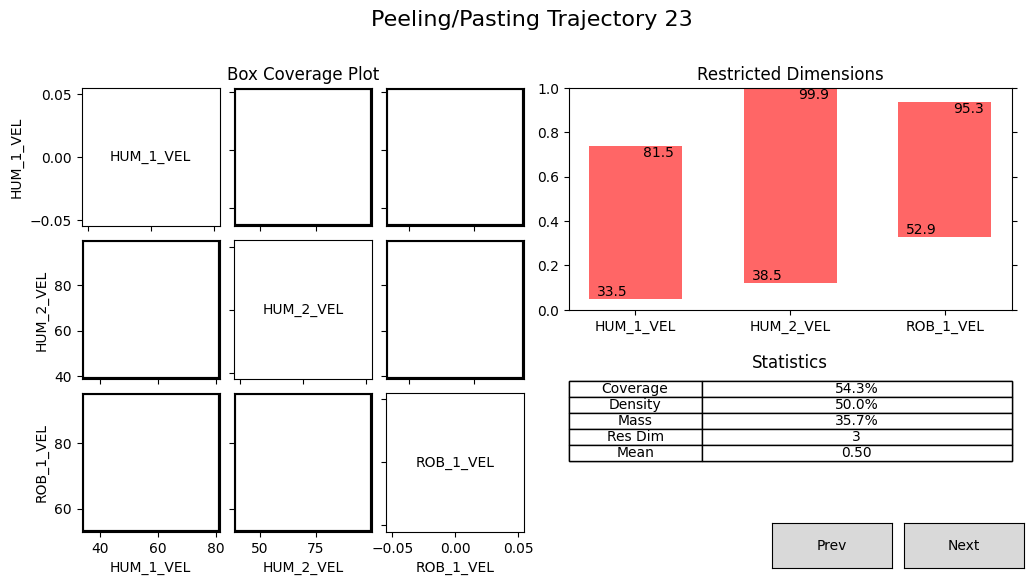

{'HUM_1_VEL': {'min': 33.524467255938646, 'max': 81.52867324704451},
 'HUM_2_VEL': {'min': 38.505570132448, 'max': 99.9499765529545},
 'ROB_1_VEL': {'min': 52.942476613101505, 'max': 95.3237971866759}}

In [145]:
# Rhodium
# fig = plt.figure(figsize=(24,12))
box1.show_tradeoff()
box1.show_details()
plt.show()

ArchSpace.get_box_limits(box1)[['min', 'max']].to_dict(orient='index')

Reducing range for tradeoff: high,high {'PRSCS_UPPER_BOUND': (0.7323333333333335, 1.1), 'DUMMY': (0.7030000000000001, 1.1)}
New ranges: {'HUM_1_VEL': {'min': 33.524467255938646, 'max': 81.52867324704451}, 'HUM_2_VEL': {'min': 38.505570132448, 'max': 99.9499765529545}, 'ROB_1_VEL': {'min': 52.942476613101505, 'max': 95.3237971866759}}
Experiments: (89, 6)


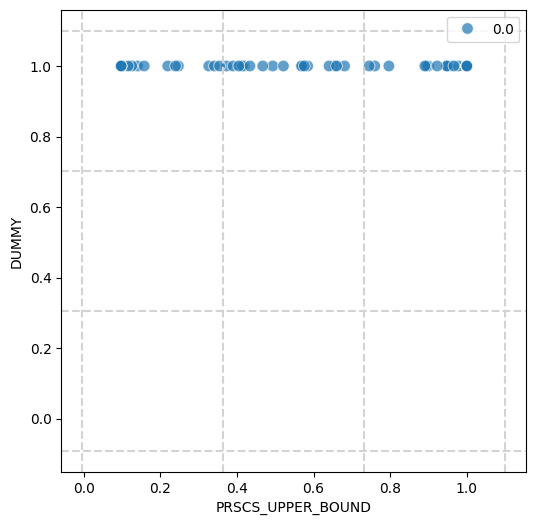

In [146]:
my_space.import_dataset(X_test, y_test)
# my_space.import_dataset(X_train, y_train)

print("Reducing range for tradeoff:", qa_label, property_to_check)
print("New ranges:",  prange)

my_space.adjust_parameters(prange)
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
print("Experiments:", my_space.experiments_df_.shape)

df = my_space.outcomes_df_.copy()
df['decision'] = my_space.experiments_df_['policy']
show_quality_attribute_space2D(df, MIN_MAX_RANGES, 
                               # qualities=['PRSCS_UPPER_BOUND1', 'PRSCS_UPPER_BOUND2'], 
                               qualities=['PRSCS_UPPER_BOUND', 'DUMMY'],
                               alpha=0.7)

---